In [2]:
import numpy as np 
import pandas as pd 
import os

In [3]:
import keras
from keras.models import Sequential
from keras.layers import Conv2D,Flatten,Dense,MaxPooling2D,Dropout
from sklearn.metrics import accuracy_score

In [4]:
import ipywidgets as widgets
import io
from PIL import Image
import tqdm
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf

In [5]:
X_train = []
Y_train = []
image_size = 150
labels = ['glioma_tumor','meningioma_tumor','no_tumor','pituitary_tumor']
for i in labels:
    folderPath = os.path.join('dataset/Training', i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        Y_train.append(i)
        
for i in labels:
    folderPath = os.path.join('dataset/Testing', i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size,image_size))
        X_train.append(img)
        Y_train.append(i)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

In [6]:
X_train,Y_train = shuffle(X_train,Y_train,random_state=101)
X_train.shape

(3264, 150, 150, 3)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train,
    Y_train,
    test_size=0.1,
    random_state=101,
    stratify=Y_train
)


X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [8]:
y_train = [labels.index(label) for label in y_train]
y_train = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_test = [labels.index(label) for label in y_test]
y_test = tf.keras.utils.to_categorical(y_test, num_classes=4)

Convolutional Neural Network

In [9]:
model = Sequential()
model.add(Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same',
    input_shape=(150,150,3)
))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Dropout(0.3))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512,activation = 'relu'))
model.add(Dense(512,activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(4,activation='softmax'))

In [10]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 64)      18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 74, 74, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 72, 72, 64)        36928     
                                                                 
 conv2d_3 (Conv2D)           (None, 70, 70, 64)        36928     
                                                        

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=32,
    verbose=1
)

Epoch 1/20


83/83 [==============================] - 149s 2s/step - loss: 1.3663 - accuracy: 0.2796 - val_loss: 1.3331 - val_accuracy: 0.2517
Epoch 2/20
83/83 [==============================] - 146s 2s/step - loss: 1.3310 - accuracy: 0.3106 - val_loss: 1.3441 - val_accuracy: 0.2585
Epoch 3/20
83/83 [==============================] - 143s 2s/step - loss: 1.2162 - accuracy: 0.4453 - val_loss: 1.3506 - val_accuracy: 0.4830
Epoch 4/20
83/83 [==============================] - 143s 2s/step - loss: 0.9173 - accuracy: 0.6126 - val_loss: 0.8519 - val_accuracy: 0.5952
Epoch 5/20
83/83 [==============================] - 144s 2s/step - loss: 0.7769 - accuracy: 0.6769 - val_loss: 0.7711 - val_accuracy: 0.6429
Epoch 6/20
83/83 [==============================] - 147s 2s/step - loss: 0.6951 - accuracy: 0.7215 - val_loss: 0.6624 - val_accuracy: 0.7143
Epoch 7/20
83/83 [==============================] - 143s 2s/step - loss: 0.5822 - accuracy: 0.7586 - val_loss: 0.7384 - val_accuracy: 0.6429
Epoch 8/20


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

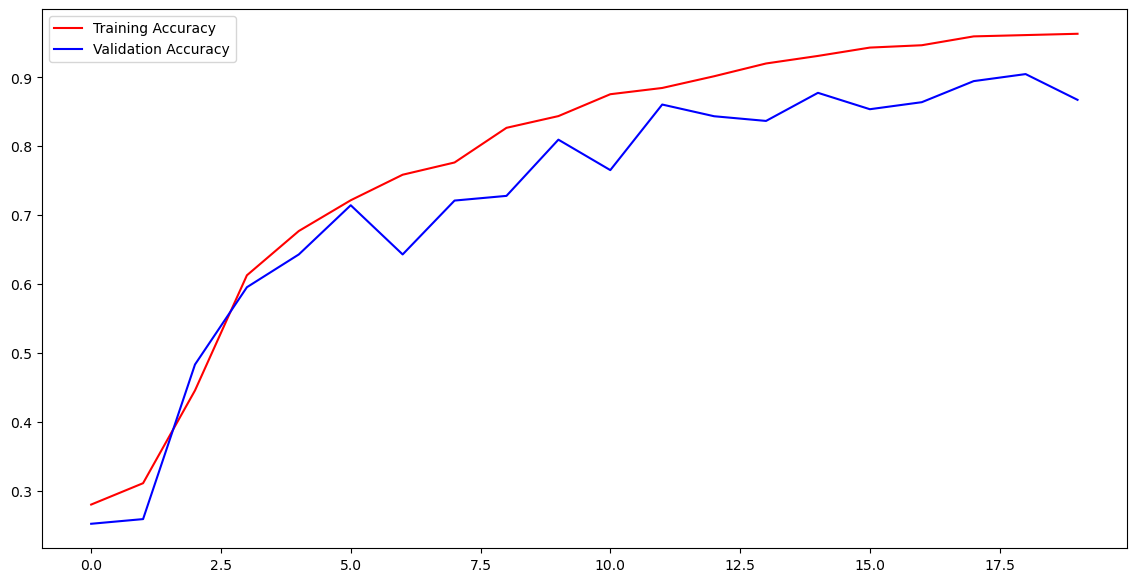

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,acc,'r',label="Training Accuracy")
plt.plot(epochs,val_acc,'b',label="Validation Accuracy")
plt.legend(loc='upper left')
plt.show()

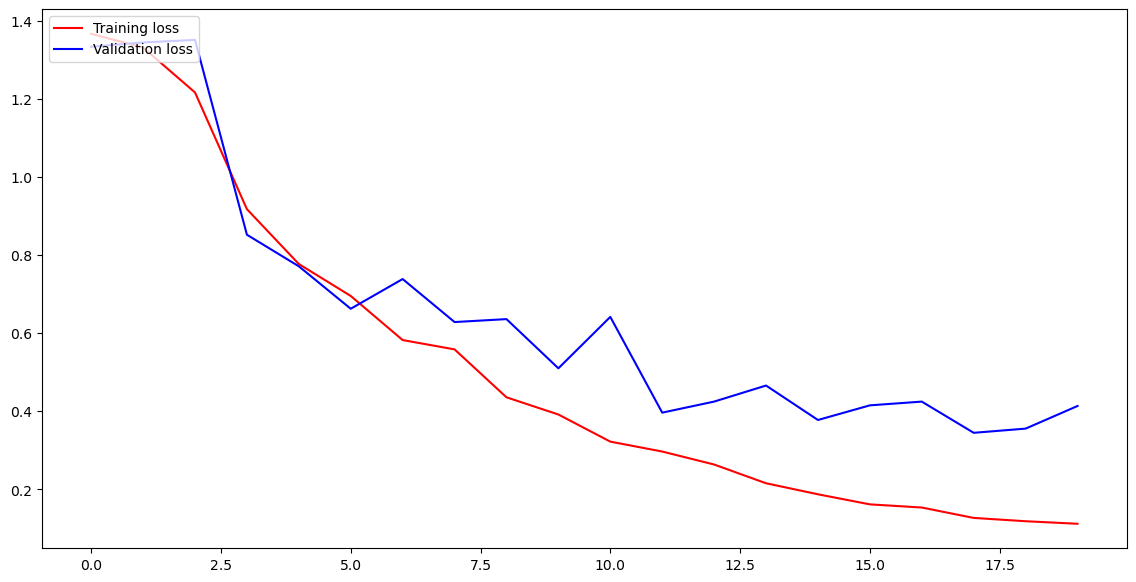

In [15]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
fig = plt.figure(figsize=(14,7))
plt.plot(epochs,loss,'r',label="Training loss")
plt.plot(epochs,val_loss,'b',label="Validation loss")
plt.legend(loc='upper left')
plt.show()

Prediction

In [16]:
img = cv2.imread('dataset/Training/pituitary_tumor/p (107).jpg')
img = cv2.resize(img,(150,150))
img_array = np.array(img)
img_array.shape

(150, 150, 3)

In [17]:
img_array = img_array.reshape(1,150,150,3)
img_array.shape

(1, 150, 150, 3)

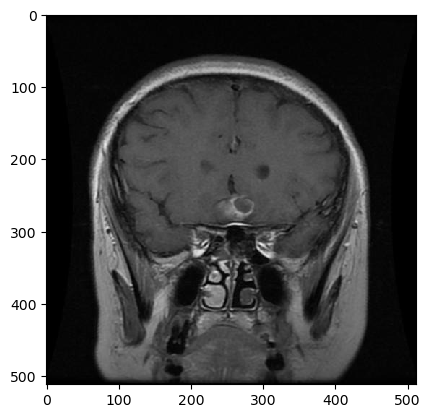

In [18]:
from tensorflow.keras.preprocessing import image
img = image.load_img('dataset/Training/pituitary_tumor/p (107).jpg')
plt.imshow(img,interpolation='nearest')
plt.show()

In [19]:
a=model.predict(img_array)
indices = a.argmax()
indices

1/1 [==============================] - 1s 503ms/step


2

In [20]:
model.save("brain_tumor_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [21]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

11/11 [==============================] - 5s 413ms/step - loss: 0.3035 - accuracy: 0.9052
Test Loss: 0.3035
Test Accuracy: 0.9052


In [24]:
class_names = {
    "glioma_tumor": "Glioma Tumor",
    "meningioma_tumor": "Meningioma Tumor",
    "no_tumor": "No Tumor",
    "pituitary_tumor": "Pituitary Tumor"
}
prediction = labels[np.argmax(a)]
confidence = np.max(a) * 100

print("Prediction:", class_names[prediction])
print(f"Confidence: {confidence:.2f}%")

Prediction: No Tumor
Confidence: 100.00%


In [25]:
!pip freeze > requirements.txt

In [26]:
import os

print(os.path.exists("requirements.txt"))

True


In [27]:
with open("requirements.txt", "r") as f:
    print(f.read()[:1000])

absl-py==2.0.0
accelerate==1.2.1
aiobotocore @ file:///C:/b/abs_1c1a_vjay2/croot/aiobotocore_1682537737724/work
aiofiles @ file:///C:/b/abs_9ex6mi6b56/croot/aiofiles_1683773603390/work
aiohttp @ file:///C:/b/abs_b78zt6vo64/croot/aiohttp_1694181126607/work
aioitertools @ file:///tmp/build/80754af9/aioitertools_1607109665762/work
aiosignal @ file:///tmp/build/80754af9/aiosignal_1637843061372/work
aiosqlite @ file:///C:/b/abs_9djc_0pyi3/croot/aiosqlite_1683773915844/work
alabaster @ file:///home/ktietz/src/ci/alabaster_1611921544520/work
altair==5.3.0
anaconda-anon-usage @ file:///C:/b/abs_f4tsjyl9va/croot/anaconda-anon-usage_1695310457827/work
anaconda-catalogs @ file:///C:/b/abs_8btyy0o8s8/croot/anaconda-catalogs_1685727315626/work
anaconda-client @ file:///C:/b/abs_80wttmgui4/croot/anaconda-client_1694625288614/work
anaconda-cloud-auth @ file:///C:/b/abs_5cjpnu6wjb/croot/anaconda-cloud-auth_1694462130037/work
anaconda-navigator @ file:///C:/b/abs_ab00e0_u7e/croot/anaconda-navigator_169

In [28]:
import streamlit

print(streamlit.__version__)

1.32.2


In [30]:
import sys
print(sys.executable)

C:\Users\vanar\anaconda3\python.exe


In [ ]:
import sys
!{sys.executable} -m streamlit run app.py